<a href="https://colab.research.google.com/github/VrishinCR7/RL_chess_model/blob/main/chess_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Designing a Learning Agent for Optimal Chess Moves
!pip install python-chess tqdm matplotlib torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 75.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for chess: filename=chess-1.11.2-py3-none-any.whl size=147775 sha256=74e641bfc140ee13147683f2bdd561e4e614376b2137f52dea5f87583d2220cc
  Stored in directory: /root/.cache/pip/wheels/83/1f/4e/8f4300f7dd554eb8de70ddfed96e94d3d030ace10c5b53d447
Successfully built chess


In [2]:
# FULL CHESS AGENT IMPLEMENTATION FOR COLAB
# -----------------------------------------

import chess
import chess.pgn
import random
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
from tqdm import tqdm

# ========== BOARD ENCODING ==========
PIECE_TO_IDX = {
    chess.PAWN: 0,
    chess.KNIGHT: 1,
    chess.BISHOP: 2,
    chess.ROOK: 3,
    chess.QUEEN: 4,
    chess.KING: 5,
}

def board_to_tensor(board):
    arr = np.zeros((12, 8, 8), dtype=np.float32)
    for sq in chess.SQUARES:
        p = board.piece_at(sq)
        if p:
            idx = PIECE_TO_IDX[p.piece_type]
            channel = idx + (0 if p.color == chess.WHITE else 6)
            arr[channel, 7 - chess.square_rank(sq), chess.square_file(sq)] = 1.0
    return arr

def legal_mask(board):
    mask = np.zeros(4096, dtype=np.float32)
    for mv in board.legal_moves:
        mask[mv.from_square * 64 + mv.to_square] = 1.0
    return mask

def idx_to_move(idx):
    return chess.Move(idx // 64, idx % 64)

# ========== POLICY NETWORK ==========
class PolicyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(768, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 4096)
        )

    def forward(self, x):
        return self.net(x)

# ========== AGENT ==========
class REINFORCEAgent:
    def __init__(self, device="cuda"):
        self.device = device
        self.policy = PolicyNet().to(device)
        self.opt = optim.Adam(self.policy.parameters(), lr=3e-4)

    def choose_move(self, board):
        state = torch.tensor(board_to_tensor(board), device=self.device).unsqueeze(0)
        logits = self.policy(state).squeeze()
        mask = torch.tensor(legal_mask(board), device=self.device)

        logits[mask == 0] = -1e9
        probs = torch.softmax(logits, dim=-1)

        idx = torch.multinomial(probs, 1).item()
        move = idx_to_move(idx)
        return move, torch.log(probs[idx])

    def update(self, logps, rewards, gamma=0.99):
        R = 0
        returns = []
        for r in reversed(rewards):
            R = r + gamma * R
            returns.insert(0, R)
        returns = torch.tensor(returns, device=self.device)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        loss = 0
        for logp, R in zip(logps, returns):
            loss -= logp * R

        self.opt.zero_grad()
        loss.backward()
        self.opt.step()

# ========== TRAINING LOOP ==========
def play_game(agent, opponent=None, device="cuda"):
    board = chess.Board()
    logps, rewards = [], []

    while not board.is_game_over():
        if board.turn == chess.WHITE:
            move, logp = agent.choose_move(board)
            logps.append(logp)
        else:
            move = random.choice(list(board.legal_moves))

        board.push(move)

    result = board.result()
    reward = 1 if result == "1-0" else (-1 if result == "0-1" else 0)
    rewards = [reward] * len(logps)
    return logps, rewards, result

def train(agent, episodes=200):
    history = {"win":0, "loss":0, "draw":0}

    for ep in tqdm(range(episodes)):
        logps, rewards, result = play_game(agent)

        agent.update(logps, rewards)

        if result == "1-0": history["win"] += 1
        elif result == "0-1": history["loss"] += 1
        else: history["draw"] += 1

        if (ep+1) % 50 == 0:
            print("Stats:", history)

    return history


In [3]:
def evaluate(board):
    """
    Heuristic evaluation function for Minimax.
    Positive score → favors White.
    Negative score → favors Black.
    """
    # Terminal game states
    if board.is_checkmate():
        return -9999 if board.turn == chess.WHITE else 9999
    if board.is_stalemate() or board.is_insufficient_material():
        return 0

    score = 0

    # Material scoring
    for sq in chess.SQUARES:
        piece = board.piece_at(sq)
        if piece:
            val = PIECE_VALUES[piece.piece_type]
            score += val if piece.color == chess.WHITE else -val

    # Mobility scoring
    mobility = len(list(board.legal_moves))
    score += 0.01 * mobility * (1 if board.turn == chess.WHITE else -1)

    return score


# -----------------------------
# Minimax with Alpha-Beta
# -----------------------------

def minimax(board, depth, alpha, beta, maximizing):
    """
    Minimax algorithm with Alpha-Beta pruning.
    Returns: (evaluation_score, best_move)
    """
    if depth == 0 or board.is_game_over():
        return evaluate(board), None

    best_move = None

    if maximizing:
        max_eval = -math.inf
        for move in board.legal_moves:
            board.push(move)
            eval_score, _ = minimax(board, depth - 1, alpha, beta, False)
            board.pop()

            if eval_score > max_eval:
                max_eval = eval_score
                best_move = move

            alpha = max(alpha, eval_score)
            if beta <= alpha:
                break  # beta cutoff

        return max_eval, best_move

    else:
        min_eval = math.inf
        for move in board.legal_moves:
            board.push(move)
            eval_score, _ = minimax(board, depth - 1, alpha, beta, True)
            board.pop()

            if eval_score < min_eval:
                min_eval = eval_score
                best_move = move

            beta = min(beta, eval_score)
            if beta <= alpha:
                break  # alpha cutoff

        return min_eval, best_move


# -----------------------------
# Minimax Agent Wrapper
# -----------------------------

class MinimaxAgent:
    def __init__(self, depth=2):
        self.depth = depth

    def select_move(self, board):
        """
        Uses minimax to select the best move.
        """
        score, move = minimax(
            board,
            self.depth,
            -math.inf,
            math.inf,
            maximizing=(board.turn == chess.WHITE)
        )
        # fallback in case no move found
        return move if move else random.choice(list(board.legal_moves))

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
agent = REINFORCEAgent(device=device)

print("Training...")
history = train(agent, episodes=500)
print(history)


Training...


 10%|█         | 50/500 [00:16<02:02,  3.66it/s]

Stats: {'win': 4, 'loss': 5, 'draw': 41}


 20%|██        | 101/500 [00:33<01:39,  4.03it/s]

Stats: {'win': 7, 'loss': 9, 'draw': 84}


...

Stats: {'win': 21, 'loss': 44, 'draw': 335}


 90%|█████████ | 450/500 [02:31<00:17,  2.78it/s]

Stats: {'win': 22, 'loss': 48, 'draw': 380}


100%|██████████| 500/500 [02:49<00:00,  2.95it/s]

Stats: {'win': 24, 'loss': 51, 'draw': 425}
{'win': 24, 'loss': 51, 'draw': 425}


In [5]:
torch.save(agent.policy.state_dict(), "chess_rl_agent.pth")

from google.colab import files
files.download("chess_rl_agent.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
!pip install chessboard

from chessboard import display
import time

def watch_game(agent):
    board = chess.Board()
    gui = display.start()

    while not board.is_game_over():
        move, _ = agent.choose_move(board)
        board.push(move)
        display.update(board.fen())
        time.sleep(0.4)


  Preparing metadata (setup.py) ... done
  Created wheel for bprofile: filename=bprofile-1.3.4-py3-none-any.whl size=30956 sha256=ecb53c61a6aef253a598aa9f0eada0b6e512b7282b74d590d083a6eccfe6de61
  Stored in directory: /root/.cache/pip/wheels/44/40/38/886888a3b79d9684b9926483f61fb752b8d1a86bf8cfdd9e98
Successfully built bprofile


AttributeError: module 'platform' has no attribute 'linux_distribution'

In [7]:
def play_user_vs_ai(agent):
    board = chess.Board()
    print(board)

    while not board.is_game_over():
        if board.turn == chess.WHITE:
            move_str = input("Your move: ")
            board.push(chess.Move.from_uci(move_str))
        else:
            ai_move, _ = agent.choose_move(board)
            print("AI plays:", ai_move)
            board.push(ai_move)

        print(board)


In [8]:
from IPython.display import SVG, display
import chess.svg

def show_board(board):
    display(SVG(chess.svg.board(board=board)))


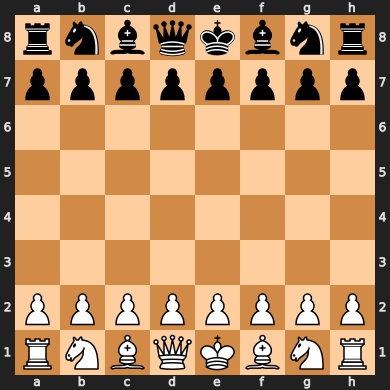

In [9]:
import chess

board = chess.Board()
show_board(board)


In [10]:
import time

def watch_ai_play(agent, delay=0.5):
    board = chess.Board()

    while not board.is_game_over():
        show_board(board)
        move, _ = agent.choose_move(board)
        board.push(move)
        time.sleep(delay)

    show_board(board)
    print("Game Over:", board.result())


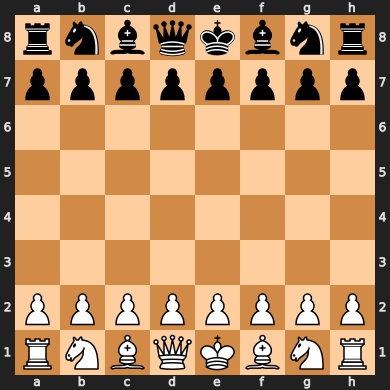

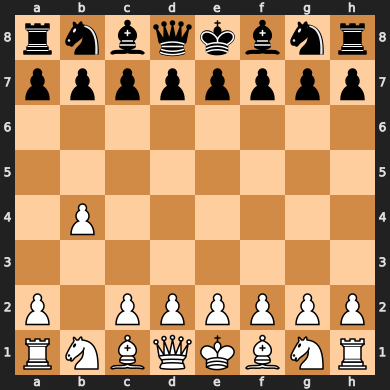

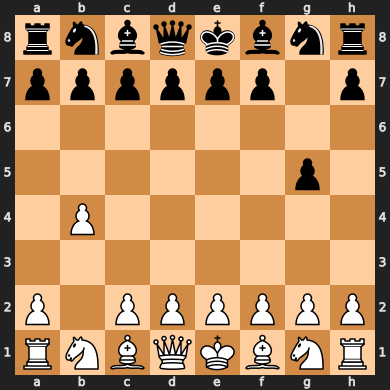

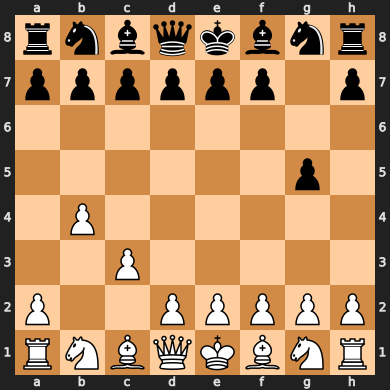

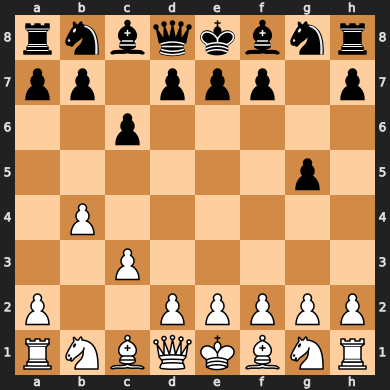

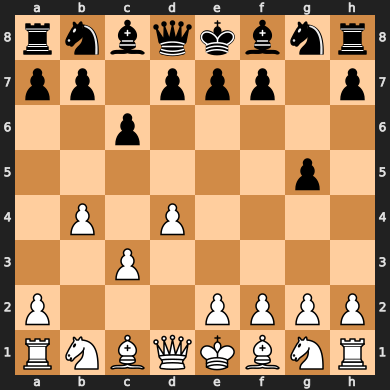

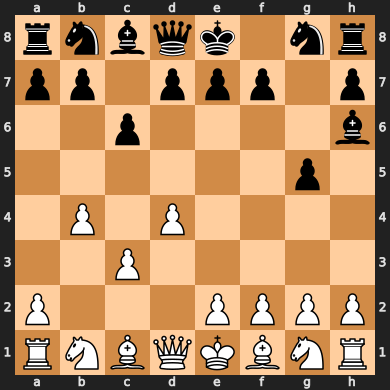

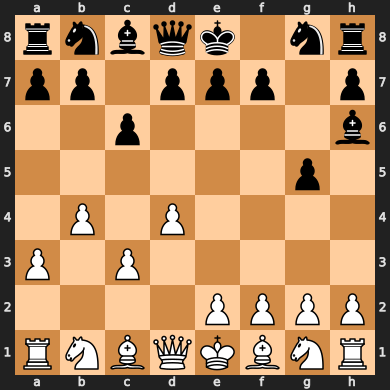

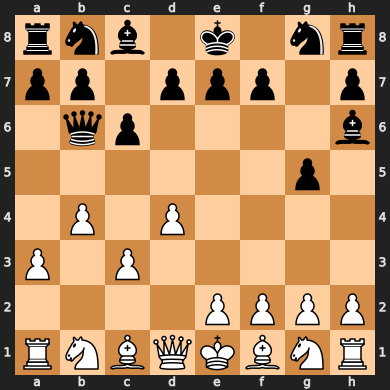

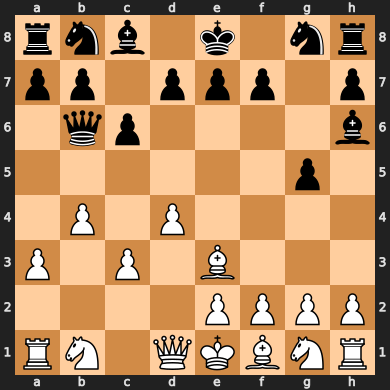

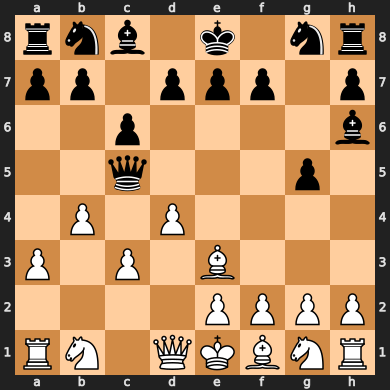

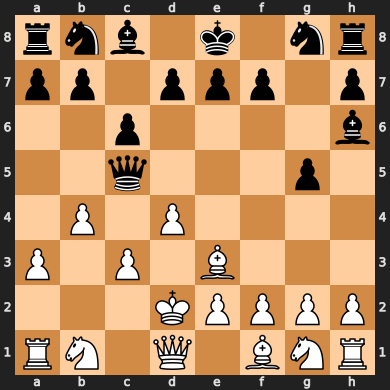

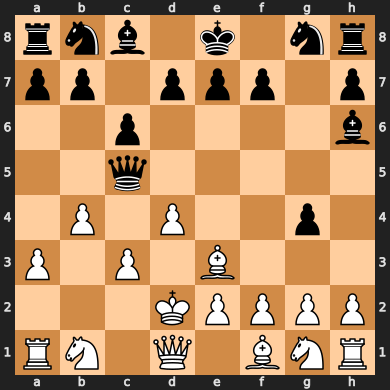

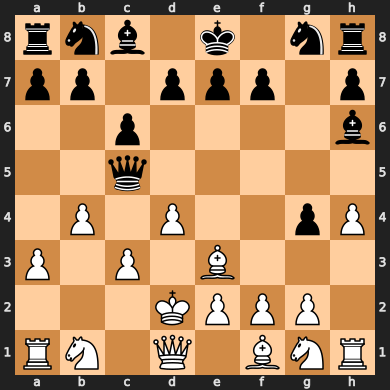

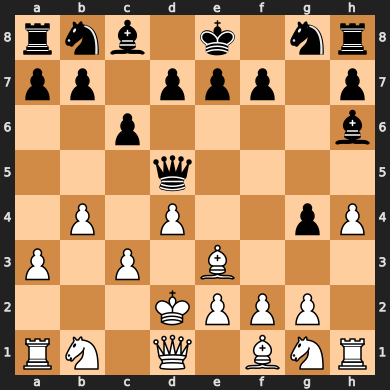

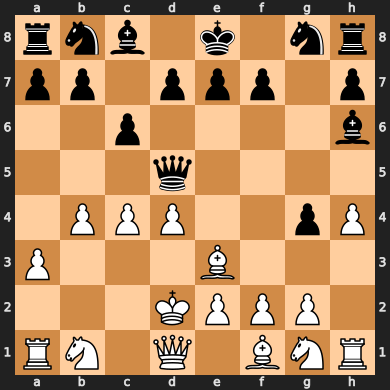

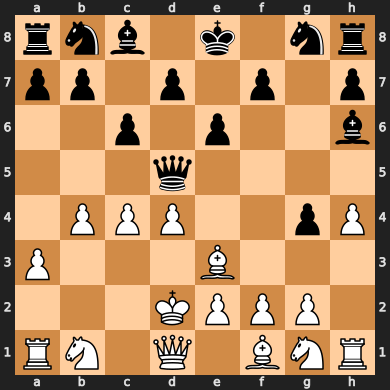

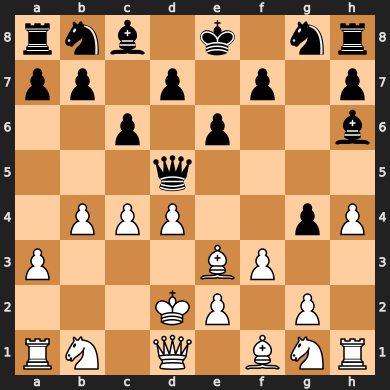

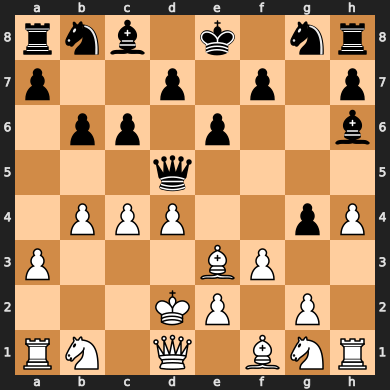

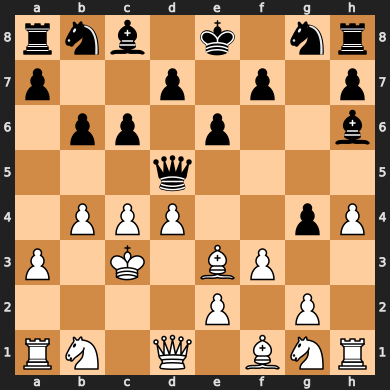

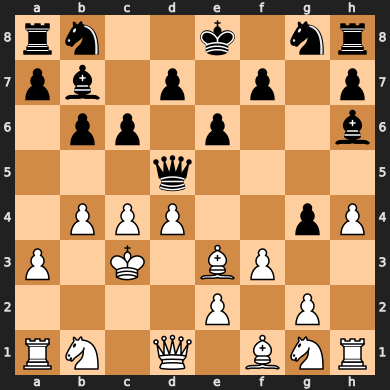

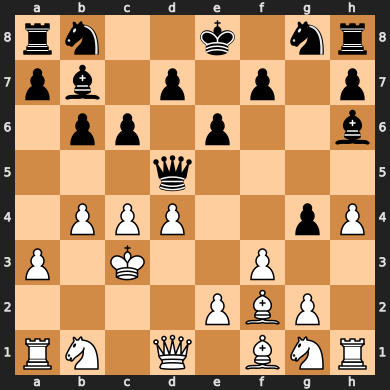

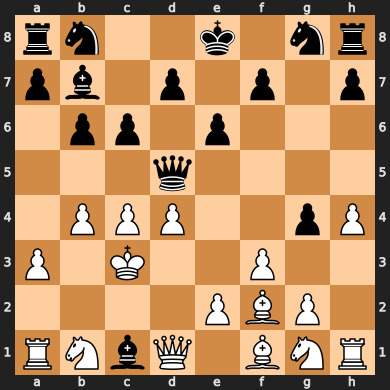

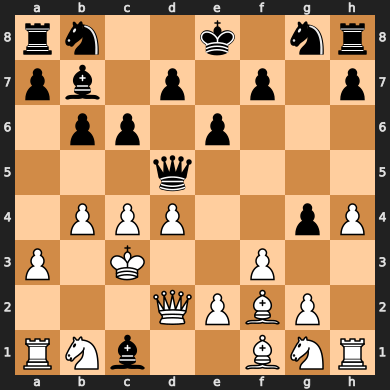

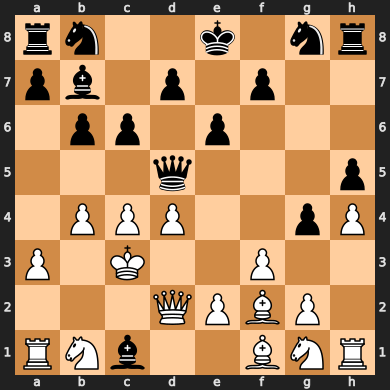

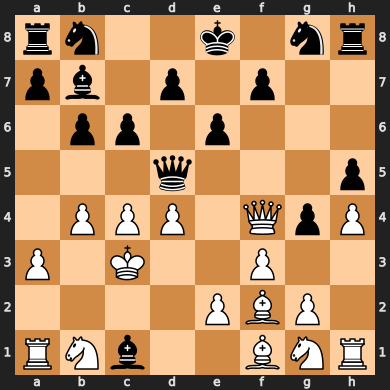

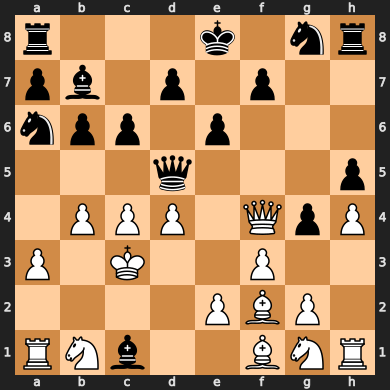

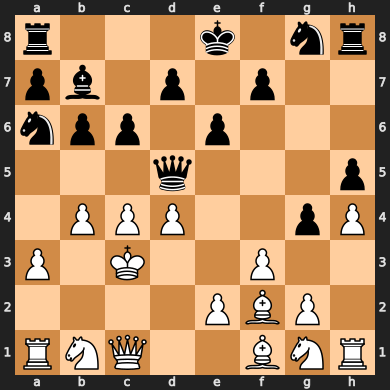

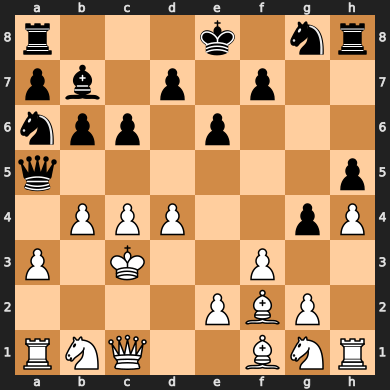

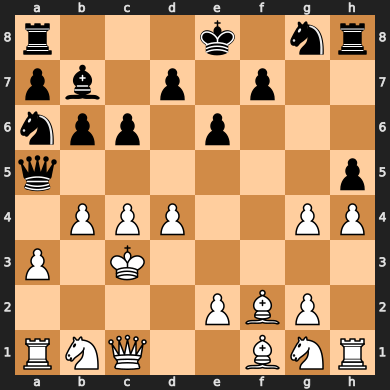

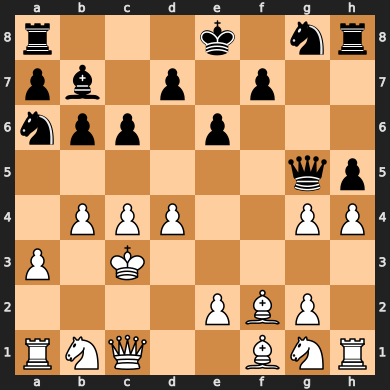

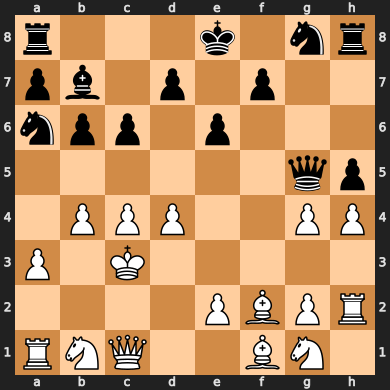

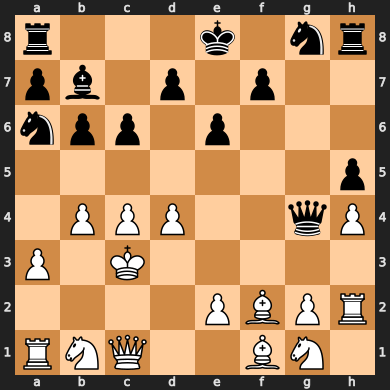

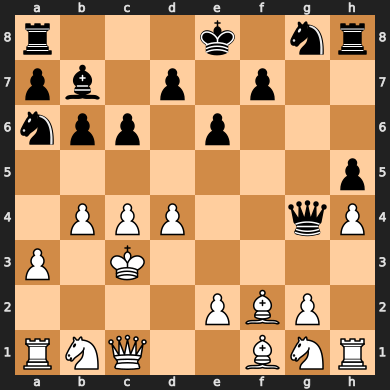

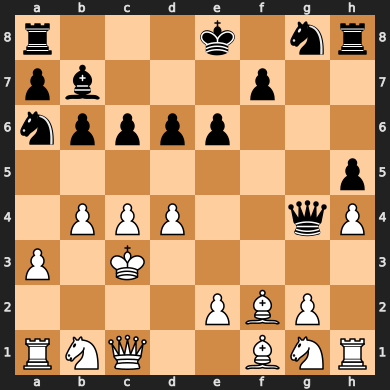

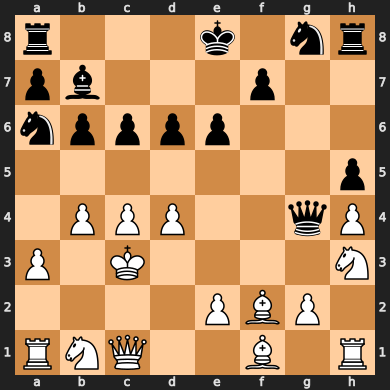

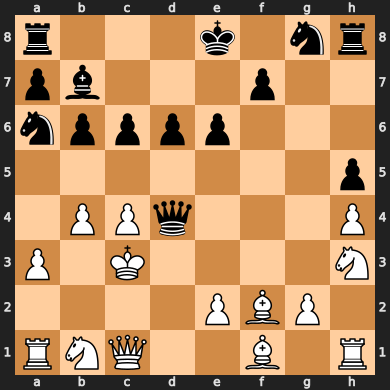

KeyboardInterrupt: 

In [11]:
watch_ai_play(agent)


In [12]:
import chess
import random

def generate_test_positions(n=10):
    """Generate a list of random but legal test positions."""
    positions = []

    for _ in range(n):
        board = chess.Board()

        # play random legal moves to reach a midgame position
        for _ in range(random.randint(8, 20)):
            if board.is_game_over():
                break
            move = random.choice(list(board.legal_moves))
            board.push(move)

        positions.append(board.copy())

    return positions

# Example:
test_positions = generate_test_positions(10)
len(test_positions)


10

In [13]:
import numpy as np
import torch

def evaluate_agent(agent, games=20, opponent_type="random", device="cuda"):
    results = {"wins":0, "losses":0, "draws":0}
    move_counts = []
    entropies = []

    for g in range(games):
        board = chess.Board()
        moves_played = 0

        while not board.is_game_over():
            # WHITE: policy agent
            if board.turn == chess.WHITE:
                move, logp = agent.choose_move(board)
                entropy = -(torch.exp(logp) * logp).item()
                entropies.append(entropy)
            else:
                # BLACK: opponent
                if opponent_type == "random":
                    move = random.choice(list(board.legal_moves))
                elif opponent_type == "minimax":
                    move = MinimaxAgent(depth=2).select_move(board)
                else:
                    raise ValueError("Unknown opponent type")

            board.push(move)
            moves_played += 1

        # game result
        res = board.result()
        move_counts.append(moves_played)

        if res == "1-0":
            results["wins"] += 1
        elif res == "0-1":
            results["losses"] += 1
        else:
            results["draws"] += 1

    # compute stats
    metrics = {
        "Win Rate": results["wins"] / games,
        "Loss Rate": results["losses"] / games,
        "Draw Rate": results["draws"] / games,
        "Avg Game Length": np.mean(move_counts),
        "Avg Policy Entropy": np.mean(entropies),
    }

    return metrics


In [14]:
import matplotlib.pyplot as plt

def plot_training_curves(history):
    wins = history["wins"]
    losses = history["losses"]
    draws = history["draws"]

    plt.figure(figsize=(10,6))
    plt.plot(wins, label="Wins")
    plt.plot(losses, label="Losses")
    plt.plot(draws, label="Draws")
    plt.title("Training Performance Over Episodes")
    plt.xlabel("Episode")
    plt.ylabel("Count")
    plt.legend()
    plt.grid()
    plt.show()


In [15]:
def move_quality(agent, positions, depth=2):
    matches = 0

class MinimaxAgent:
    def __init__(self, depth=2):
        self.depth = depth

    def select_move(self, board):
        score, move = minimax(
            board,
            self.depth,
            -math.inf,
            math.inf,
            maximizing=(board.turn == chess.WHITE)
        )
        return move if move else random.choice(list(board.legal_moves))

    mm = MinimaxAgent(depth)

    for board in positions:
        ai_move, _ = agent.choose_move(board)
        mm_move = mm.select_move(board)

        if ai_move == mm_move:
            matches += 1

return matches / len(positions)


NameError: name 'depth' is not defined

In [16]:
def save_agent(agent, path="policy_model.pth"):
    torch.save(agent.policy.state_dict(), path)
    print("Model saved:", path)


In [17]:
def load_agent(agent, path="policy_model.pth", device="cuda"):
    agent.policy.load_state_dict(torch.load(path, map_location=device))
    print("Model loaded:", path)


In [18]:
def tournament(agent1, agent2, games=20):
    results = {"agent1":0, "agent2":0, "draw":0}

    for g in range(games):
        board = chess.Board()

        while not board.is_game_over():
            if board.turn == chess.WHITE:
                move = agent1.choose_move(board)[0]
            else:
                move = agent2.choose_move(board)[0]

            board.push(move)

        res = board.result()

        if res == "1-0":
            results["agent1"] += 1
        elif res == "0-1":
            results["agent2"] += 1
        else:
            results["draw"] += 1

    return results


In [19]:
def inspect_policy(agent, board):
    state = torch.tensor(board_to_tensor(board), device=agent.device).unsqueeze(0)
    logits = agent.policy(state).squeeze()
    mask = torch.tensor(legal_mask(board), device=agent.device)

    logits[mask == 0] = -1e9
    probs = torch.softmax(logits, dim=0)

    move_probs = []
    for move in board.legal_moves:
        idx = move.from_square * 64 + move.to_square
        move_probs.append((move, probs[idx].item()))

    move_probs.sort(key=lambda x: -x[1])
    return move_probs[:10]  # top 10 moves


In [20]:
def test_on_puzzles(agent, puzzle_fens):
    correct = 0

    for fen, solution in puzzle_fens:
        board = chess.Board(fen)
        move, _ = agent.choose_move(board)
        if move.uci() == solution:
            correct += 1

    return correct / len(puzzle_fens)


In [21]:
common_openings = [
    chess.Board("rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1"), # King's Pawn
    chess.Board("rnbqkbnr/pppppppp/8/8/3NP3/8/PPP1PPPP/R1BQKBNR b KQkq - 0 1"), # Scotch
    chess.Board("rnbqkbnr/pp1ppppp/8/2p5/3PP3/5N2/PPP2PPP/RNBQKB1R b KQkq - 0 1"), # Sicilian
]


In [22]:
for b in common_openings:
    print(inspect_policy(agent, b))


[(Move.from_uci('c7c6'), 0.5559945702552795), (Move.from_uci('h7h5'), 0.11270194500684738), (Move.from_uci('h7h6'), 0.08755567669868469), (Move.from_uci('g7g5'), 0.05251405015587807), (Move.from_uci('d7d5'), 0.036900658160448074), (Move.from_uci('e7e5'), 0.03276481851935387), (Move.from_uci('d7d6'), 0.02212388813495636), (Move.from_uci('c7c5'), 0.02088557742536068), (Move.from_uci('e7e6'), 0.018679168075323105), (Move.from_uci('g7g6'), 0.017910132184624672)]
[(Move.from_uci('c7c6'), 0.5273968577384949), (Move.from_uci('h7h5'), 0.11572518199682236), (Move.from_uci('h7h6'), 0.0906466394662857), (Move.from_uci('g7g5'), 0.05569716915488243), (Move.from_uci('d7d5'), 0.03939532861113548), (Move.from_uci('e7e5'), 0.035180043429136276), (Move.from_uci('d7d6'), 0.024037932977080345), (Move.from_uci('c7c5'), 0.02256697043776512), (Move.from_uci('e7e6'), 0.020564232021570206), (Move.from_uci('g7g6'), 0.019983459264039993)]
[(Move.from_uci('h7h5'), 0.20978479087352753), (Move.from_uci('h7h6'), 0.1

In [23]:
from IPython.display import display, SVG
import chess.svg

def show(board, last_move=None):
    """
    Display board as SVG in Colab.
    Optionally highlight the last move.
    """
    if last_move:
        svg = chess.svg.board(board, lastmove=last_move, size=400)
    else:
        svg = chess.svg.board(board, size=400)

    display(SVG(svg))



In [24]:
def visualize_best_move(agent, board):
    # get top predicted move
    top_moves = inspect_policy(agent, board)
    best_move, prob = top_moves[0]

    print("Best move predicted:", best_move.uci(), "with probability:", prob)

    # show board BEFORE move
    print("Before move:")
    show(board)

    # show board AFTER move with highlight
    temp_board = board.copy()
    temp_board.push(best_move)
    print("After move:")
    show(temp_board, last_move=best_move)


Best move predicted: b2b4 with probability: 0.7758862972259521
Before move:


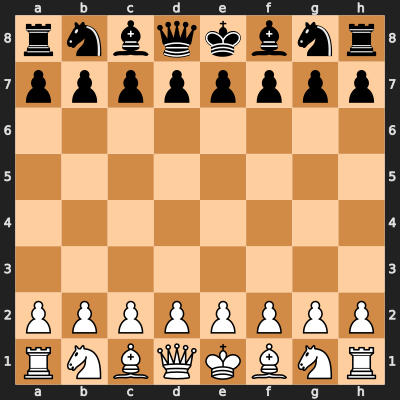

After move:


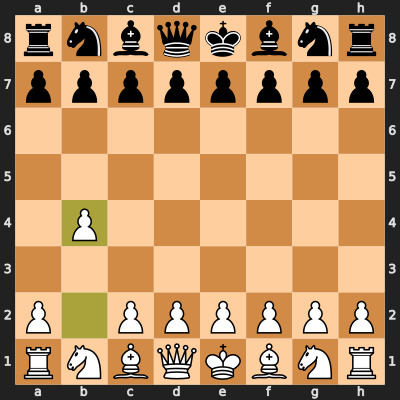

In [25]:
visualize_best_move(agent, board)


In [26]:
# Define piece values (classic chess engine weights)
import chess, math, random

PIECE_VALUES = {
    chess.PAWN:   1,
    chess.KNIGHT: 3,
    chess.BISHOP: 3,
    chess.ROOK:   5,
    chess.QUEEN:  9,
    chess.KING:   0
}

def evaluate_position(board):
    """
    Evaluation function that uses PIECE_VALUES.
    Positive -> good for White, Negative -> good for Black.
    """
    if board.is_checkmate():
        # If it's White's turn and it's checkmate, White was mated (bad for White)
        return -9999 if board.turn == chess.WHITE else 9999
    if board.is_stalemate() or board.is_insufficient_material():
        return 0

    score = 0
    for sq in chess.SQUARES:
        p = board.piece_at(sq)
        if p:
            score += PIECE_VALUES[p.piece_type] * (1 if p.color == chess.WHITE else -1)

    # mobility heuristic (small weight)
    mobility = len(list(board.legal_moves))
    score += 0.01 * mobility * (1 if board.turn == chess.WHITE else -1)

    return score

# sanity quick-check
b = chess.Board()
print("Sanity check evaluate_position(initial):", evaluate_position(b))


Sanity check evaluate_position(initial): 0.2


In [27]:
import chess
import random
import numpy as np

def build_test_dataset(samples=300, depth=2):
    X, y = [], []
    mm = MinimaxAgent(depth=depth)

    for _ in range(samples):
        board = chess.Board()

        # create random midgame position
        for _ in range(random.randint(8, 20)):
            if board.is_game_over():
                break
            move = random.choice(list(board.legal_moves))
            board.push(move)

        best_move = mm.select_move(board)
        label = best_move.from_square * 64 + best_move.to_square

        X.append(board_to_tensor(board))
        y.append(label)

    return np.array(X), np.array(y)

X_test, y_test = build_test_dataset(300)


In [28]:
import torch

def predict_moves(agent, X):
    preds = []
    agent.policy.eval()

    for state in X:
        t = torch.tensor(state).unsqueeze(0).to(agent.device)
        logits = agent.policy(t).squeeze()

        probs = torch.softmax(logits, dim=0)
        pred = torch.argmax(probs).item()
        preds.append(pred)

    return np.array(preds)

y_pred = predict_moves(agent, X_test)


In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Accuracy: 0.0
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, zero_division=0))


              precision    recall  f1-score   support

          24       0.00      0.00      0.00       1.0
          40       0.00      0.00      0.00       1.0
          74       0.00      0.00      0.00       1.0
          89       0.00      0.00      0.00       1.0
         137       0.00      0.00      0.00       3.0
         139       0.00      0.00      0.00       1.0
         157       0.00      0.00      0.00       1.0
         166       0.00      0.00      0.00       2.0
         175       0.00      0.00      0.00       1.0
         202       0.00      0.00      0.00       1.0
         209       0.00      0.00      0.00       2.0
         211       0.00      0.00      0.00       4.0
         213       0.00      0.00      0.00       1.0
         216       0.00      0.00      0.00       2.0
         219       0.00      0.00      0.00       1.0
         222       0.00      0.00      0.00       1.0
         269       0.00      0.00      0.00       1.0
         332       0.00    

In [31]:
def top_k_accuracy(agent, X, y, k=5):
    correct = 0

    for i, state in enumerate(X):
        t = torch.tensor(state).unsqueeze(0).to(agent.device)
        logits = agent.policy(t).squeeze()
        probs = torch.softmax(logits, dim=0)

        topk = torch.topk(probs, k).indices.cpu().numpy()
        if y[i] in topk:
            correct += 1

    return correct / len(y)

print("Top-3 Accuracy:", top_k_accuracy(agent, X_test, y_test, k=3))
print("Top-5 Accuracy:", top_k_accuracy(agent, X_test, y_test, k=5))


Top-3 Accuracy: 0.0
Top-5 Accuracy: 0.0


In [32]:
from sklearn.metrics import confusion_matrix
import numpy as np

unique_moves = np.unique(np.concatenate([y_test, y_pred]))
cm = confusion_matrix(y_test, y_pred, labels=unique_moves)

print("Confusion Matrix Shape:", cm.shape)


Confusion Matrix Shape: (206, 206)


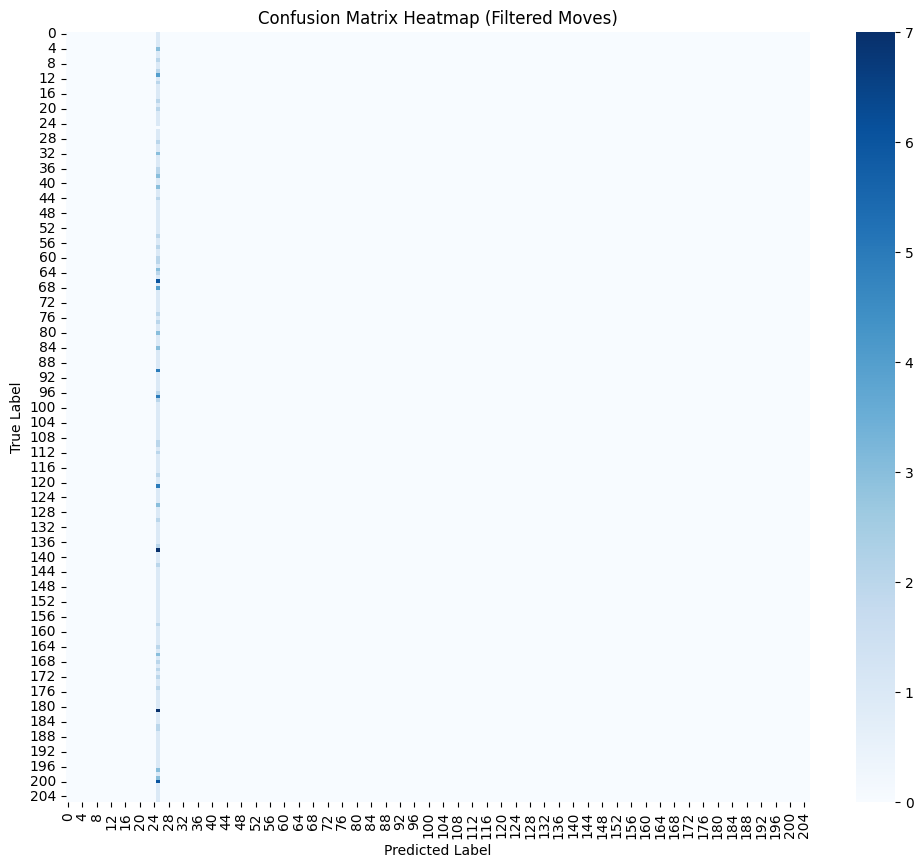

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix Heatmap (Filtered Moves)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


/tmp/ipykernel_408/523551757.py:2: RuntimeWarning: invalid value encountered in divide
  sns.heatmap(cm / cm.sum(axis=1, keepdims=True),


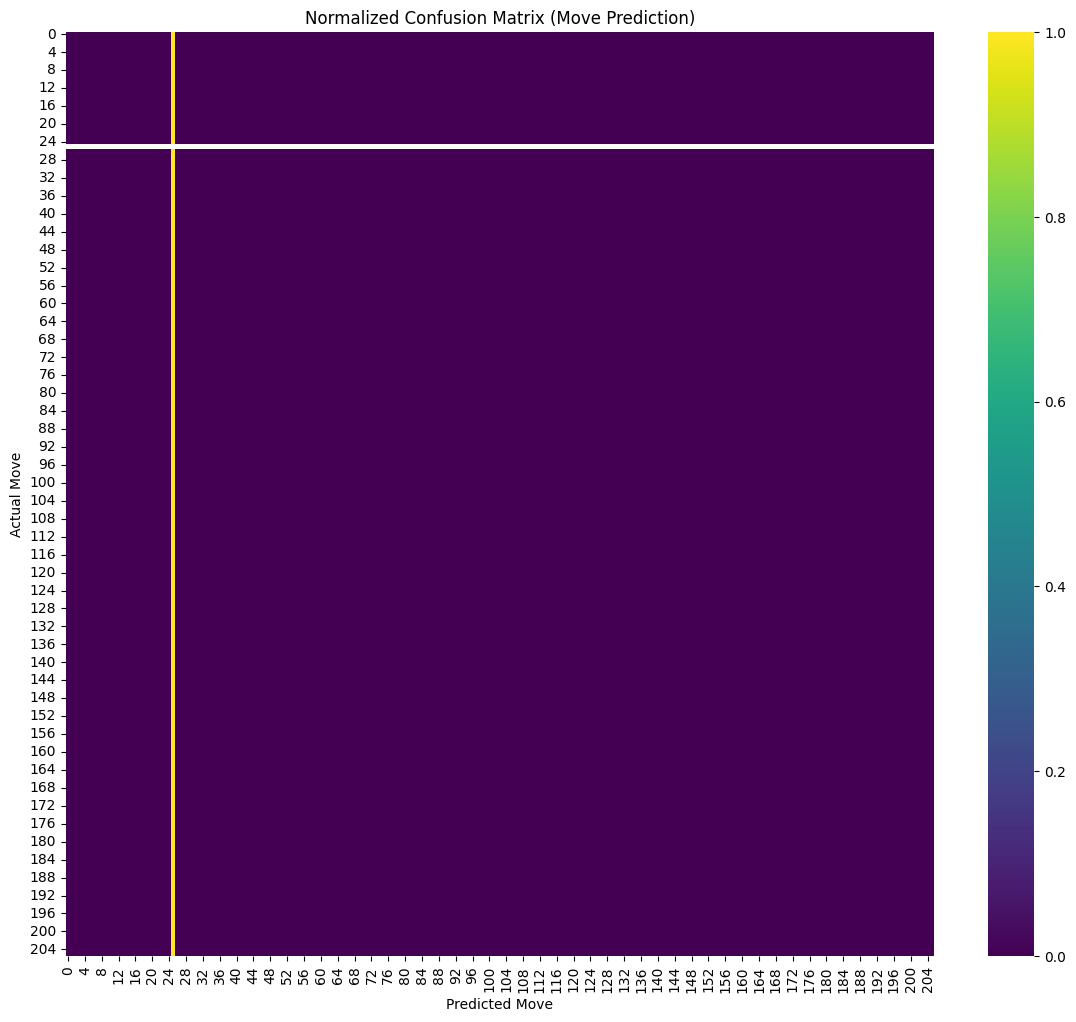

In [34]:
plt.figure(figsize=(14, 12))
sns.heatmap(cm / cm.sum(axis=1, keepdims=True),
            cmap="viridis",
            annot=False)
plt.title("Normalized Confusion Matrix (Move Prediction)")
plt.xlabel("Predicted Move")
plt.ylabel("Actual Move")
plt.show()


In [35]:
from IPython.display import Markdown

def pretty_print_metrics():
    display(Markdown(f"""
### 📊 Model Evaluation Metrics

| Metric | Value |
|--------|--------|
| Accuracy | {accuracy:.4f} |
| Precision | {precision:.4f} |
| Recall | {recall:.4f} |
| F1 Score | {f1:.4f} |
| Top-3 Accuracy | {top_k_accuracy(agent, X_test, y_test, 3):.4f} |
| Top-5 Accuracy | {top_k_accuracy(agent, X_test, y_test, 5):.4f} |
"""))

pretty_print_metrics()



### 📊 Model Evaluation Metrics

| Metric | Value |
|--------|--------|
| Accuracy | 0.0000 |
| Precision | 0.0000 |
| Recall | 0.0000 |
| F1 Score | 0.0000 |
| Top-3 Accuracy | 0.0000 |
| Top-5 Accuracy | 0.0000 |


In [36]:
import matplotlib.pyplot as plt

def plot_training_stats(history):
    wins = history["wins"]
    losses = history["losses"]
    draws = history["draws"]

    plt.figure(figsize=(12,6))
    plt.plot(wins, label="Wins", linewidth=2)
    plt.plot(losses, label="Losses", linewidth=2)
    plt.plot(draws, label="Draws", linewidth=2)

    plt.title("Training Performance Over Episodes", fontsize=18)
    plt.xlabel("Episode", fontsize=14)
    plt.ylabel("Count", fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=14)
    plt.show()


In [37]:
def plot_accuracy():
    plt.plot([1,2,3])
    plt.show()



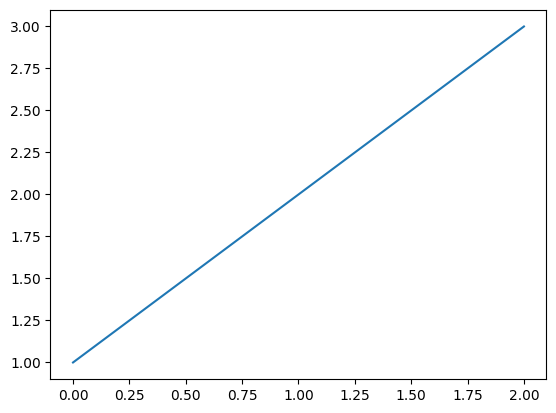

In [38]:
 plot_accuracy()

In [39]:
def plot_outcome_ratio(history):
    wins = np.array(history["wins"])
    losses = np.array(history["losses"])
    draws = np.array(history["draws"])

    episodes = np.arange(len(wins))

    plt.figure(figsize=(12,6))
    plt.stackplot(episodes, wins, losses, draws,
                  labels=["Wins", "Losses", "Draws"],
                  alpha=0.85)

    plt.title("Outcome Distribution Over Training", fontsize=18)
    plt.xlabel("Episode", fontsize=14)
    plt.ylabel("Frequency", fontsize=14)
    plt.legend(loc="upper left", fontsize=14)
    plt.show()


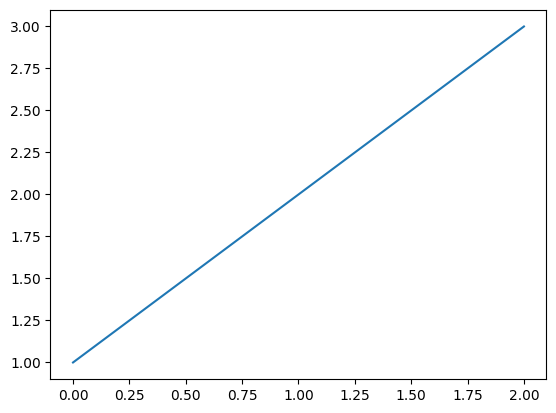

In [40]:
 plot_accuracy()

In [43]:
def plot_accuracy_metrics(accuracy, precision, recall, f1):
    metrics = [accuracy, precision, recall, f1]
    names = ["Accuracy", "Precision", "Recall", "F1 Score"]

    plt.figure(figsize=(8,6))
    plt.bar(names, metrics, alpha=0.8)

    plt.title("Model Evaluation Metrics", fontsize=18)
    plt.ylabel("Score", fontsize=14)
    plt.ylim(0, 1)
    plt.plot(accuracy,precison)
    plt.grid(axis="y", alpha=0.3)
    plt.show()
